In [1]:
import os
import math
import random
import sys
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoConfig

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

torch.set_float32_matmul_precision("high")

# paths (aligned with 01-2.motivation_toy.ipynb)
os.chdir('/home/seunghan.lee/workspace/cross-rag/motivation/')
ROOT = Path('cross-rag/').resolve().parent.parent  # /home/.../workspace/cross-rag
sys.path.append(str(ROOT / "cross-rag"))
BASE_CONFIG_DIR = ROOT / "checkpoints" / "base"
DUALHEAD_CKPT_DIR = ROOT / "checkpoints" / "pretrain_Chronos_lb512_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7"
DUALHEAD_CKPT = DUALHEAD_CKPT_DIR / "best.pth"

import sys
sys.path.append(str(ROOT))

from models.ChronosBolt import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_base
from models.ChronosBolt_TabPFN_dualhead_R_as_key import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_ours

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


print("ROOT:", ROOT)
print("DUALHEAD_CKPT:", DUALHEAD_CKPT)
print("device:", device)
assert DUALHEAD_CKPT.exists(), "checkpoint not found; update path if needed"
assert BASE_CONFIG_DIR.exists(), "base config dir not found"

# helper to load model (mirrors 01-2.motivation_toy)
def load_model(ckpt_file: Path, cls, augment: str | None = None):
    cfg = AutoConfig.from_pretrained(BASE_CONFIG_DIR, trust_remote_code=True)
    state = torch.load(ckpt_file, map_location=device)
    extra = {"augment": augment} if augment is not None else {}
    model = cls.from_pretrained(BASE_CONFIG_DIR, config=cfg, state_dict=state, **extra)
    return model.to(device).eval()

model = load_model(DUALHEAD_CKPT, ChronosBoltModelForForecastingWithRetrieval_ours, augment="moe")

# configs
context_len = 512
pred_len = 64
N = 100          # knowledge base size
k_top = 5        # top-k to retrieve

sns.set_style("whitegrid")



/usr/local/lib/python3.10/dist-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


ROOT: /home/seunghan.lee/workspace/ts-rag
DUALHEAD_CKPT: /home/seunghan.lee/workspace/ts-rag/checkpoints/pretrain_Chronos_lb512_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7/best.pth
device: cpu
self.chronos_config.context_length 2048


In [20]:

# parameter range
noise_range = (0.03, 0.12)
trend_range = (-0.01, 0.01)
season_count_range = (1, 3)
freq_range = (1.0, 6.0)
amp_range = (0.4, 1.6)
level_range = (-0.5, 0.5)

# Signal generation function
def make_signal(length, cfg=None,
                noise_range=noise_range,
                trend_range=trend_range,
                season_count_range=season_count_range,
                freq_range=freq_range,
                amp_range=amp_range,
                level_range=level_range):
    t = np.arange(length)
    if cfg is not None:
        trend = cfg.get("trend", 0.0) * t
        level = cfg.get("level", 0.0)
        noise_std = cfg.get("noise_std", np.random.uniform(*noise_range))
        seasons = cfg.get("seasons", [])
        sig = trend + level
        if len(seasons) == 0:
            num_seasons = np.random.randint(season_count_range[0], season_count_range[1] + 1)
            for _ in range(num_seasons):
                f = np.random.uniform(*freq_range) * 2
                phase = np.random.uniform(0, 2*np.pi)
                amp = np.random.uniform(*amp_range)
                sig += amp * np.sin(2 * np.pi * f * t / length + phase)
        else:
            for comp in seasons:
                f = comp.get("freq", np.random.uniform(*freq_range))
                phase = comp.get("phase", 0.0)
                amp = comp.get("amp", 1.0)
                sig += amp * np.sin(2 * np.pi * f * t / length + phase)
        sig += noise_std * np.random.randn(length)
        return sig
    # fallback random if no cfg
    trend = np.random.uniform(*trend_range) * t
    num_seasons = np.random.randint(season_count_range[0], season_count_range[1] + 1)
    sig = trend
    for _ in range(num_seasons):
        f = np.random.uniform(*freq_range) * 2
        phase = np.random.uniform(0, 2*np.pi)
        amp = np.random.uniform(*amp_range)
        sig += amp * np.sin(2 * np.pi * f * t / length + phase)
    noise = np.random.uniform(*noise_range) * np.random.randn(length)
    level = np.random.uniform(*level_range)
    sig = sig + noise + level
    return sig

# Generate random config
def generate_random_config(name_prefix, num_configs=5):
    configs = []
    for i in range(num_configs):
        num_seasons = np.random.randint(season_count_range[0], season_count_range[1] + 1)
        seasons = []
        for _ in range(num_seasons):
            seasons.append({
                "freq": np.random.uniform(*freq_range),
                "amp": np.random.uniform(*amp_range),
                "phase": np.random.uniform(0, 2*np.pi)
            })
        configs.append({
            "name": f"{name_prefix}{i}",
            "trend": np.random.uniform(*trend_range),
            "level": np.random.uniform(*level_range),
            "noise_std": np.random.uniform(*noise_range),
            "seasons": seasons
        })
    return configs


# Model attention weights calculation function
def model_cross_attention_weights(model, query_t: torch.Tensor, kb_top: torch.Tensor, pred_len: int = 64):
    device = next(model.parameters()).device
    q_ctx = query_t.to(device)
    k_ctx = kb_top.to(device)
    
    batch_size = 1
    context = q_ctx.unsqueeze(0) if q_ctx.dim() == 1 else q_ctx
    mask = torch.isnan(context).logical_not().to(context.dtype)
    
    if context.shape[-1] > model.chronos_config.context_length:
        context = context[..., -model.chronos_config.context_length:]
        mask = mask[..., -model.chronos_config.context_length:]
    
    context, _ = model.instance_norm(context)
    context = context.to(model.dtype)
    mask = mask.to(model.dtype)
    
    patched_context = model.patch(context)
    patched_mask = torch.nan_to_num(model.patch(mask), nan=0.0)
    patched_context[~(patched_mask > 0)] = 0.0
    patched_context = torch.cat([patched_context, patched_mask], dim=-1)
    
    attention_mask = patched_mask.sum(dim=-1) > 0
    
    input_embeds = model.input_patch_embedding(patched_context)
    
    if model.chronos_config.use_reg_token:
        reg_input_ids = torch.full(
            (batch_size, 1),
            model.config.reg_token_id,
            device=input_embeds.device,
        )
        reg_embeds = model.shared(reg_input_ids)
        input_embeds = torch.cat([input_embeds, reg_embeds], dim=-2)
        attention_mask = torch.cat([attention_mask, torch.ones_like(reg_input_ids)], dim=-1)
    
    encoder_outputs = model.encoder(
        attention_mask=attention_mask,
        inputs_embeds=input_embeds,
    )
    hidden_states = encoder_outputs[0]
    seq_embed = model.decode(input_embeds, attention_mask, hidden_states)

    retrieved_x = k_ctx
    retrieved_y = k_ctx[:, -pred_len:]

    retrieved_x_enc = model.encode_mlp_x(retrieved_x)
    retrieved_y_enc = model.encode_mlp_y(retrieved_y)
    retrieved_x_enc = retrieved_x_enc.unsqueeze(0)
    retrieved_y_enc = retrieved_y_enc.unsqueeze(0)

    attn_out, attn_w = model.cross_mha(
        seq_embed,
        retrieved_x_enc,
        retrieved_y_enc,
        need_weights=True,
    )
    weights = attn_w[0, 0].detach().cpu()
    return weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed

In [36]:
# ============================================================================
# Unified cell: Set only random seed to generate final figure
# ============================================================================

# Set random seed (change only this to generate various scenarios)
RANDOM_SEED = 40

def show_all(RANDOM_SEED, save=False, return_data=False):
    # Set random seed
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)


    # Generate query and retrieved configs
    query_configs = generate_random_config("q", num_configs=1)
    retrieved_configs = generate_random_config("r", num_configs=k_top)

    # Change some retrieved series to pure noise (independent of query)
    num_noise_only = max(1, k_top // 3)  # about 1/3 of total as noise only
    noise_only_indices = np.random.choice(k_top, size=num_noise_only, replace=False)
    for idx in noise_only_indices:
        # Generate config with only pure noise (trend=0, level=0, seasons=[])
        retrieved_configs[idx] = {
            "name": f"r{idx}_noise_only",
            "trend": 0.0,
            "level": 0.0,
            "noise_std": np.random.uniform(0.5, 2.0),  # larger noise
            "seasons": []  # no pattern
        }

    # Generate signal (no normalization - for model input)
    query = make_signal(context_len, cfg=query_configs[0])
    kb_top_list = []
    for c in retrieved_configs:
        if len(c.get("seasons", [])) == 0 and c.get("trend", 0) == 0 and c.get("level", 0) == 0:
            # generate only pure noise
            noise_std = c.get("noise_std", 1.0)
            sig = noise_std * np.random.randn(context_len)
            kb_top_list.append(torch.tensor(sig, dtype=torch.float32))
        else:
            kb_top_list.append(torch.tensor(make_signal(context_len, cfg=c), dtype=torch.float32))
    kb_top = torch.stack(kb_top_list)

    # for cosine similarity calculation (use min-max normalization)
    query_t = torch.tensor(query, dtype=torch.float32)
    query_minmax = (query_t - query_t.min()) / (query_t.max() - query_t.min() + 1e-12)
    kb_top_minmax = (kb_top - kb_top.min(dim=1, keepdim=True).values) / (kb_top.max(dim=1, keepdim=True).values - kb_top.min(dim=1, keepdim=True).values + 1e-12)
    query_norm_cos = query_minmax / (query_minmax.norm() + 1e-12)
    kb_norm_cos = kb_top_minmax / (kb_top_minmax.norm(dim=1, keepdim=True) + 1e-12)
    sims = torch.matmul(kb_norm_cos, query_norm_cos)


    # Calculate model attention (use input without normalization)
    attn_weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed = model_cross_attention_weights(
    #    model, query_t, kb_top, pred_len=pred_len
#         model, query_norm_cos, kb_norm_cos, pred_len=pred_len
        model, query_minmax, kb_top_minmax, pred_len=pred_len
    )
    attn_weights_model = attn_weights.clone()
    if return_data:
        return attn_weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed, query_minmax, kb_top_minmax

    print(f"Random seed: {RANDOM_SEED}")
    print(f"Cosine similarities: {sims.tolist()}")
    print(f"Model attention weights: {attn_weights_model.tolist()}")

    # generate final plot
    fig, axes = plt.subplots(2, 3, figsize=(14, 6))
    axes = axes.flatten()

    # Query plot
    axes[0].plot(query, color='black', lw=1.2)
    axes[0].set_title("Query", fontsize=20)
    axes[0].set_yticks([])
    axes[0].set_xticks([])

    # sort by attention weight
    order = torch.argsort(attn_weights_model, descending=True).tolist()

    # Retrieved series plot
    for pos, idx_i in enumerate(order):
        if pos >= k_top:
            break
        ax = axes[pos + 1]
        ax.plot(kb_top[idx_i].numpy(), lw=1.2)
        ax.set_title("Retrieved:", fontsize=20, loc='left')
        ax.text(0.4, 1.01, f"Attention = {attn_weights_model[idx_i]:.2f}", color='red', fontsize=20,
                transform=ax.transAxes, ha='left', va='bottom')
        ax.set_yticks([])
        ax.set_xticks([])

    # hide unused axes
    for j in range(k_top + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    if save:
        SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
        fn = "attention.pdf"
        fn = os.path.join(SAVE_PATH,fn)
        plt.savefig(fn, bbox_inches="tight")
        plt.show()
    else:
        plt.show()



In [37]:
out = show_all(RANDOM_SEED=304, save=False, return_data=True)
attn_weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed, query_minmax, kb_top_minmax = out

Random seed: 56
Cosine similarities: [0.5525797605514526, 0.8079870939254761, 0.9791180491447449, 0.8780531287193298, 0.6609823107719421]
Model attention weights: [0.04571569338440895, 0.015477650798857212, 0.1943960338830948, 0.7102258801460266, 0.034184735268354416]


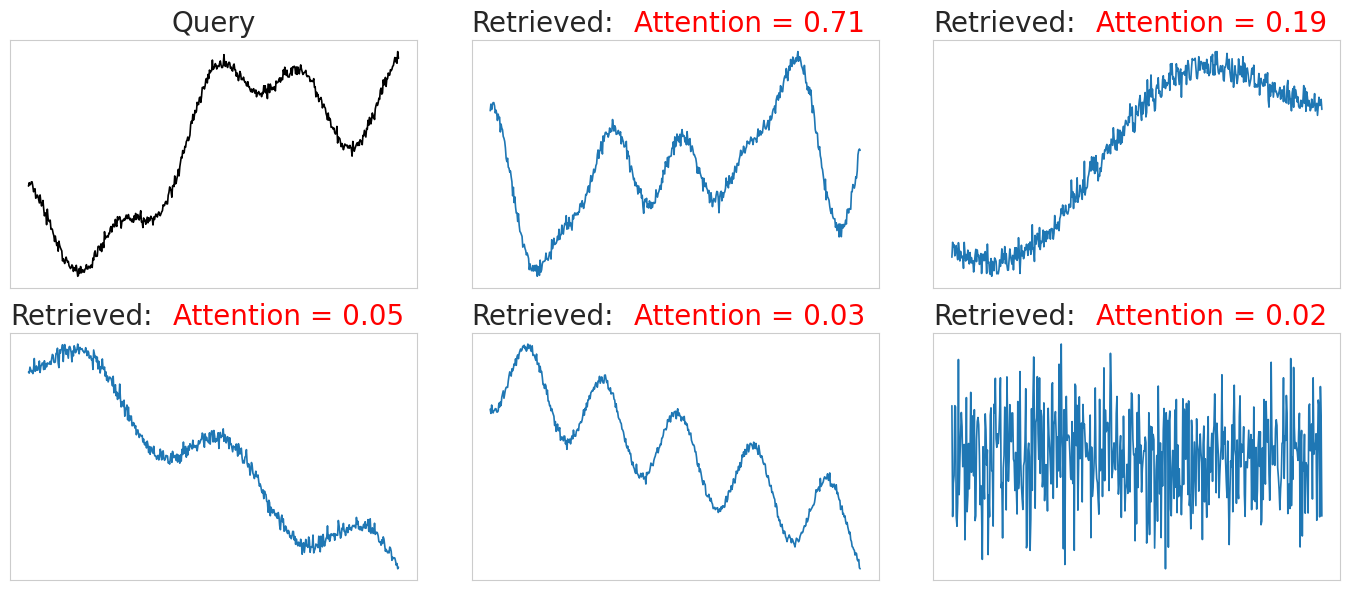

Random seed: 304
Cosine similarities: [0.7268550395965576, 0.9704902172088623, 0.8145456314086914, 0.7791579365730286, 0.8510276675224304]
Model attention weights: [0.1135747879743576, 0.35552990436553955, 0.263409286737442, 0.24384216964244843, 0.023643814027309418]


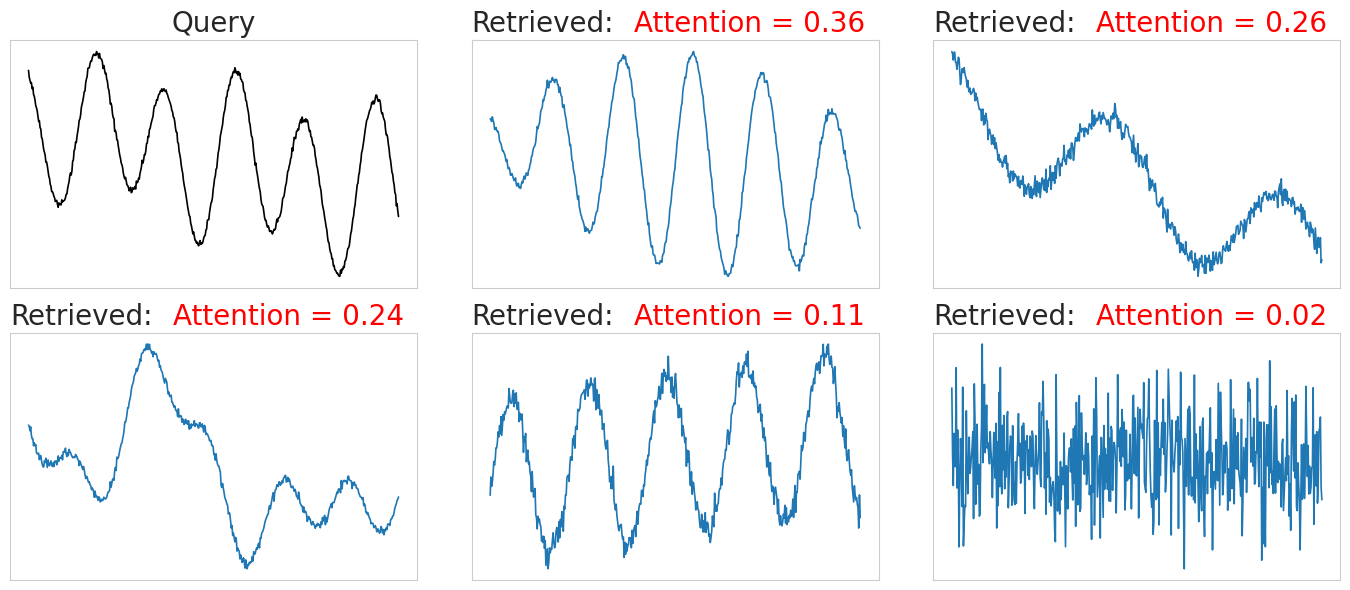

Random seed: 304
Cosine similarities: [0.7268550395965576, 0.9704902172088623, 0.8145456314086914, 0.7791579365730286, 0.8510276675224304]
Model attention weights: [0.1135747879743576, 0.35552990436553955, 0.263409286737442, 0.24384216964244843, 0.023643814027309418]


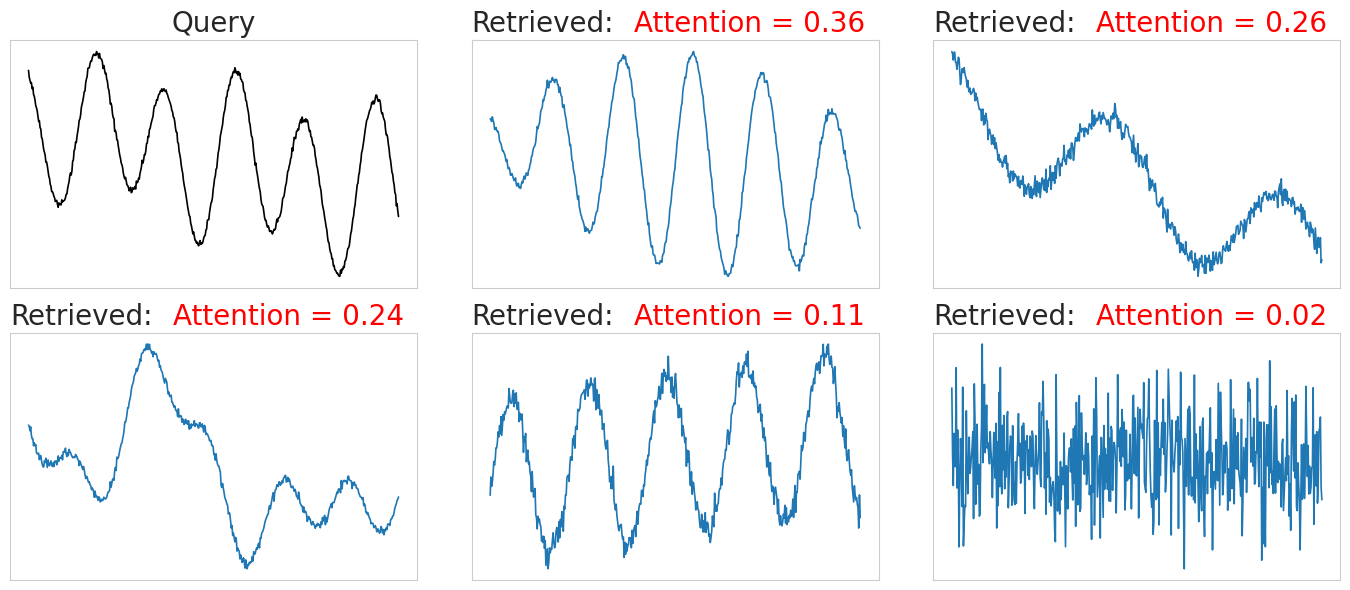

In [35]:
# 56, 104, 120, 137,304
# up to 330
RANDOM_SEED = 40
for RANDOM_SEED in [56, 304]:
#for RANDOM_SEED in [56, 104, 120, 137,304]:
    show_all(RANDOM_SEED)
for RANDOM_SEED in [304]:
#for RANDOM_SEED in [56, 104, 120, 137,304]:
    show_all(RANDOM_SEED,save=True)    

In [38]:
out = show_all(RANDOM_SEED=304, save=False, return_data=True)
attn_weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed, query_minmax, kb_top_minmax = out

In [39]:
print('retrieved_x_enc.shape',retrieved_x_enc.shape)
print('retrieved_y_enc.shape',retrieved_y_enc.shape)
print('seq_embed.shape',seq_embed.shape)
print('query_minmax.shape',query_minmax.shape)
print('kb_top_minmax.shape',kb_top_minmax.shape)
print('attn_weights.shape',attn_weights.shape)

retrieved_x_enc.shape torch.Size([1, 5, 768])
retrieved_y_enc.shape torch.Size([1, 5, 768])
seq_embed.shape torch.Size([1, 1, 768])
query_minmax.shape torch.Size([512])
kb_top_minmax.shape torch.Size([5, 512])
attn_weights.shape torch.Size([5])
